In [1]:
import pandas as pd

In [2]:
!pip install ultralytics -qq

In [ ]:
import shutil
shutil.rmtree("/kaggle/working/runs")

In [3]:
import os
import shutil

# Define source directories (the original dataset)
base_dir = '/kaggle/input/autism-image-data/AutismDataset'  # Path to your dataset
train_dir = os.path.join(base_dir, 'train')
# val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Define target directories (where organized files will be stored)
working_dir = '/kaggle/working/AutismDataset'
organized_train_dir = os.path.join(working_dir, 'train')
organized_val_dir = os.path.join(working_dir, 'val')
organized_test_dir = os.path.join(working_dir, 'test')

# Class names inferred from the file names
class_names = ['Autistic', 'Non_Autistic']

# Function to separate files into class directories
def organize_data_by_class(source_dir, target_dir, class_names):
    # Ensure target directories exist
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
    for class_name in class_names:
        class_dir = os.path.join(target_dir, class_name)
        if not os.path.exists(class_dir):
            os.makedirs(class_dir)
    
    # Move files from source_dir to corresponding class directories in target_dir
    for file_name in os.listdir(source_dir):
        if file_name.endswith('.jpg') or file_name.endswith('.png'):
            for class_name in class_names:
                image = file_name.split(".")
                if class_name == image[0]:
                    src_path = os.path.join(source_dir, file_name)
                    dest_path = os.path.join(target_dir, class_name, file_name)
                    shutil.copy(src_path, dest_path)  # Copy files instead of moving to preserve original

# Organize images in train, val, and test directories
organize_data_by_class(train_dir, organized_train_dir, class_names)
# organize_data_by_class(val_dir, organized_val_dir, class_names)
organize_data_by_class(test_dir, organized_test_dir, class_names)




Data organization completed in /kaggle/working/AutismDataset.


In [4]:

shutil.copytree("/kaggle/input/autism-image-data/AutismDataset/valid/", "/kaggle/working/AutismDataset/val")

'/kaggle/working/AutismDataset/val'

In [5]:
import yaml

# Define the structure of the YAML file
data = {
    
    'train': '/kaggle/working/AutismDataset/train',  # Corrected path to train folder
    'val': '/kaggle/working/AutismDataset/val',      # Path to validation folder
    'test': '/kaggle/working/AutismDataset/test',    # Path to test folder (optional)
    'nc': 2,                                         # Number of classes
    'names': ['Autistic', 'Non_Autistic']            # Class names
}

# Define the path where you want to save the YAML file
yaml_file_path = '/kaggle/working/AutismDataset.yaml'

# Create and write the YAML file
with open(yaml_file_path, 'w') as file:
    yaml.dump(data, file, default_flow_style=False)




YAML file created at /kaggle/working/AutismDataset.yaml


In [6]:
from ultralytics import YOLO

# Define paths
data_yaml = '/kaggle/working/AutismDataset.yaml'  # Update with the path to your dataset YAML file

# Initialize the YOLOv8-m model for classification
model = YOLO('yolov8m-cls.pt')  # Pretrained YOLOv8-m for classification

# Train the model with augmentations
model.train(
    data="/kaggle/working/AutismDataset",
    epochs=30,           # Number of epochs
    imgsz=320,            # Image size
    batch=16,             # Batch size
    lr0=0.01,             # Initial learning rate
    augment=True,         # Enable built-in augmentations
    fliplr=0.5,           # Horizontal flip with 50% probability
    flipud=0.0,           # Vertical flip with 0% probability (optional)
    hsv_h=0.015,          # Adjust hue with a range of 1.5%
    hsv_s=0.7,            # Adjust saturation with a range of 70%
    hsv_v=0.4,            # Adjust brightness (value) with a range of 40%
    degrees=0.0,          # No rotation augmentation
    translate=0.1,        # Translate images up to 10% in any direction
    scale=0.5,            # Scale images between 50%-150% of original size
    shear=0.1,            # Shear images up to 10%
    momentum=0.937,       # Momentum in optimizer
    weight_decay=0.0005   # Weight decay in optimizer
)


100%|██████████| 32.7M/32.7M [00:00<00:00, 90.9MB/s]


Ultralytics YOLOv8.2.95 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=classify, mode=train, model=yolov8m-cls.pt, data=/kaggle/working/AutismDataset, epochs=30, time=None, patience=100, batch=16, imgsz=320, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_co

2024-09-17 08:07:26,006	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-09-17 08:07:26,546	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=1000 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   2655744  ultralyti

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

...

WARNING ⚠️ ClassificationModel does not support 'augment=True' prediction. Reverting to single-scale prediction.
WARNING ⚠️ ClassificationModel does not support 'augment=True' prediction. Reverting to single-scale prediction.


               classes   top1_acc   top5_acc: 100%|██████████| 4/4 [00:00<00:00,  5.34it/s]


                   all       0.88          1
Speed: 0.3ms preprocess, 3.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/train
Results saved to runs/classify/train


lr/pg0,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
lr/pg1,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
lr/pg2,▃▆██▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁
metrics/accuracy_top1,▁▃▄▂▄▄▅▇▄▅▅▅▇▇▅█▇▆▆▇▇▆▆▆▇▆▇▇██
metrics/accuracy_top5,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
train/loss,█▆▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/loss,█▆▄▆▅▄▆▄▅▃▃▃▂▄▃▃▂▃▃▄▄▄▂▂▃▂▃▂▁▄
lr/pg0,3e-05


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79262f5687c0>
curves: []
curves_results: []
fitness: 0.9399999976158142
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.8799999952316284, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9399999976158142}
save_dir: PosixPath('runs/classify/train')
speed: {'preprocess': 0.31935691833496094, 'inference': 3.4066009521484375, 'loss': 0.00186920166015625, 'postprocess': 0.0008535385131835938}
task: 'classify'
top1: 0.8799999952316284
top5: 1.0

In [13]:
results = model.predict("/kaggle/input/autism-image-data/AutismDataset/consolidated/Non_Autistic/0006.jpg")



# Access the probabilities and class names
probs = results[0].probs  # Accessing the prediction result of the first image
class_names = results[0].names  # Class names

# Get the predicted class and confidence
predicted_class = class_names[probs.top1]  # Get the top predicted class
confidence = probs.top1conf.item()  # Confidence score of the top prediction

# Output the result





WARNING ⚠️ ClassificationModel does not support 'augment=True' prediction. Reverting to single-scale prediction.
image 1/1 /kaggle/input/autism-image-data/AutismDataset/consolidated/Non_Autistic/0006.jpg: 320x320 Non_Autistic 0.93, Autistic 0.07, 8.1ms
Speed: 5.9ms preprocess, 8.1ms inference, 0.1ms postprocess per image at shape (1, 3, 320, 320)
Predicted class: Non_Autistic, Confidence: 0.93


Predicted class: Non_Autistic, Confidence: 0.93


In [15]:
# Export the model to ONNX format
model.export(format='onnx', imgsz=320)  # Adjust image size as needed


Ultralytics YOLOv8.2.95 🚀 Python-3.10.14 torch-2.4.0 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from 'runs/classify/train/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 2) (30.2 MB)

ONNX: starting export with onnx 1.16.2 opset 19...
ONNX: export success ✅ 1.0s, saved as 'runs/classify/train/weights/best.onnx' (60.2 MB)

Export complete (2.6s)
Results saved to /kaggle/working/runs/classify/train/weights
Predict:         yolo predict task=classify model=runs/classify/train/weights/best.onnx imgsz=320  
Validate:        yolo val task=classify model=runs/classify/train/weights/best.onnx imgsz=320 data=/kaggle/working/AutismDataset  
Visualize:       https://netron.app


'runs/classify/train/weights/best.onnx'

In [1]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 94.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.9 MB/s eta 0:00:00


In [32]:
import onnxruntime
import numpy as np
import cv2
import os

# Define weightage for YOLO and EfficientNet
YOLO_WEIGHTAGE = 0.6
EFFICIENTNET_WEIGHTAGE = 0.4

photo_size = 240  # Image size for EfficientNet
yolo_image_size = 320  # Image size for YOLO
efficientnet_model_file = os.path.abspath("/kaggle/input/efficient_fyp/pytorch/default/1/efficientnet_model.onnx")  # Path to EfficientNet ONNX model
yolo_model_file = os.path.abspath("/kaggle/input/yolov8_fyp/pytorch/default/1/yolov8_m.onnx")  # Path to YOLO ONNX model

# Load and preprocess image
def load_image_from_path(filename, target_size=(320, 320), transpose=False):
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    if transpose:
        img = np.transpose(img, (2, 0, 1))  # Convert to (C, H, W) for models that require it
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Inference function for ONNX models
def inference_onnx(model_path, img_path, target_size, transpose=False):
    img = load_image_from_path(img_path, target_size=target_size, transpose=transpose)
    session = onnxruntime.InferenceSession(model_path)
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    result = session.run([output_name], {input_name: img})
    return result[0][0]  # Return the result of the first image

# YOLO inference using ONNX (class and confidence)
def inference_yolo(img_path, model_path=yolo_model_file):
    result = inference_onnx(model_path, img_path, target_size=(yolo_image_size, yolo_image_size), transpose=True)
    yolo_class = np.argmax(result)  # Get the class index with the highest score
    yolo_conf = result[yolo_class]  # Get the confidence score of the top class

    
    
    return yolo_class, yolo_conf

# EfficientNet inference using ONNX (score interpretation)
def inference_efficientnet(img_path, model_path=efficientnet_model_file):
    result = inference_onnx(model_path, img_path, target_size=(photo_size, photo_size), transpose=False)
    # EfficientNet outputs a single score, typically interpreted as the probability of the positive class (Autistic)
    efficientnet_conf = result[0]  # EfficientNet outputs a single score
    
    
    # EfficientNet Class Interpretation: higher scores mean autistic (class 0), lower scores mean non-autistic (class 1)
    efficientnet_class = 0 if efficientnet_conf > 0.5 else 1  # 0: autistic, 1: non-autistic
    return efficientnet_class, efficientnet_conf

# Final prediction using both YOLO and EfficientNet with weighted scores
def predict(image_path):
    # Run inference for YOLO
    yolo_class, yolo_conf = inference_yolo(image_path)
    

    # Run inference for EfficientNet
    efficientnet_class, efficientnet_conf = inference_efficientnet(image_path)
    

    # Adjust YOLO's confidence for class "0" (Autistic)
    if yolo_class == 0:
        yolo_autistic_conf = yolo_conf  # Confidence for "Autistic" from YOLO
    else:
        yolo_autistic_conf = 1 - yolo_conf  # If YOLO predicts "Non-Autistic", use the opposite confidence

    # Combine the confidence for "Autistic" (class 0) from both YOLO and EfficientNet
    combined_conf = (YOLO_WEIGHTAGE * yolo_autistic_conf) + (EFFICIENTNET_WEIGHTAGE * efficientnet_conf)

    # Final decision: if combined confidence > 0.5, predict "Autistic"; otherwise, "Non-Autistic"
    final_class = 0 if combined_conf > 0.5 else 1  # 0: Autistic, 1: Non-Autistic
    if final_class == 1:
        combined_conf = 1 - combined_conf
    # Map class indices to class names
    class_names = ['Autistic', 'Non_Autistic']
    predicted_class_name = class_names[final_class]

    return {"predicted_class": predicted_class_name, "combined_confidence": combined_conf}


# Resisual Calculation

In [57]:
import onnxruntime as ort
import numpy as np
import cv2
import os
import json
from glob import glob

# Constants
photo_size = 240
yolo_image_size = 320
efficientnet_model_file = os.path.abspath("/kaggle/input/efficient_fyp/pytorch/default/1/efficientnet_model.onnx")
yolo_model_file = os.path.abspath("/kaggle/input/yolov8_fyp/pytorch/default/1/yolov8_m.onnx")

# Global sessions
yolo_session = None
efficientnet_session = None

def initialize_models():
    """Initialize ONNX Runtime sessions"""
    global yolo_session, efficientnet_session
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    yolo_session = ort.InferenceSession(yolo_model_file, providers=providers)
    efficientnet_session = ort.InferenceSession(efficientnet_model_file, providers=providers)

def load_image_from_path(filename, target_size=(320, 320), transpose=False):
    """Load and preprocess image"""
    img = cv2.imread(filename)
    if img is None:
        raise ValueError(f"Failed to load image: {filename}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    if transpose:
        img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)
    return img

def get_predictions(img_path):
    """Get predictions from both models"""
    # YOLO predictions
    yolo_img = load_image_from_path(img_path, (yolo_image_size, yolo_image_size), transpose=True)
    yolo_output = yolo_session.run([yolo_session.get_outputs()[0].name], 
                                 {yolo_session.get_inputs()[0].name: yolo_img})[0][0]
    yolo_class = np.argmax(yolo_output)
    yolo_probs = [float(1 - yolo_output[yolo_class]), float(yolo_output[yolo_class])] if yolo_class == 1 else [float(yolo_output[yolo_class]), float(1 - yolo_output[yolo_class])]

    # EfficientNet predictions
    efficientnet_img = load_image_from_path(img_path, (photo_size, photo_size), transpose=False)
    efficientnet_output = efficientnet_session.run([efficientnet_session.get_outputs()[0].name],
                                                 {efficientnet_session.get_inputs()[0].name: efficientnet_img})[0][0]
    efficientnet_class = 0 if efficientnet_output > 0.5 else 1
    efficientnet_pred = efficientnet_output
    if efficientnet_class == 1:
        efficientnet_pred = 1 - efficientnet_pred
    efficientnet_probs = [float(efficientnet_pred), float(1 - efficientnet_pred)]

    return yolo_probs, efficientnet_probs

def get_true_label(filename):
    """Get true label from filename"""
    return 0 if os.path.basename(filename).startswith('Autistic') else 1

def calculate_residuals(predictions, true_labels):
    """Calculate residuals for model predictions"""
    residuals = []
    for i in range(len(true_labels)):
        true_label = true_labels[i]
        pred_prob = predictions[i][true_label]
        residual = 1 - pred_prob
        residuals.append(float(residual))
    return residuals

def process_images(image_folder, batch_size=32):
    """Process images and calculate residuals"""
    image_files = glob(os.path.join(image_folder, "*.jpg"))

    true_labels = []
    yolo_predictions = []
    efficientnet_predictions = []
    
    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i + batch_size]

        for img_path in batch_files:
            try:
                true_label = get_true_label(img_path)
                true_labels.append(true_label)
                
                yolo_probs, efficientnet_probs = get_predictions(img_path)
                yolo_predictions.append(yolo_probs)
                efficientnet_predictions.append(efficientnet_probs)
                
            except Exception as e:
                continue
    
    # Calculate residuals
    yolo_residuals = calculate_residuals(yolo_predictions, true_labels)
    efficientnet_residuals = calculate_residuals(efficientnet_predictions, true_labels)
    
    # Create results
    results = []
    for i in range(len(true_labels)):
        result = {
            "residual_distribution_of_efficentnet_model": efficientnet_residuals[i],
            "residual_distribution_of_yolo_model": yolo_residuals[i]
        }
        results.append(result)
    
    # Save results
    output = {"results": results}
    with open('residuals.json', 'w') as f:
        json.dump(output, f, indent=2)
    
    
    return results

# Run the processing
initialize_models()
results = process_images("/kaggle/input/autism-image-data/AutismDataset/train/")

Found 2540 images
Processing batch 1/80


/tmp/ipykernel_36/3168558508.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  efficientnet_probs = [float(efficientnet_pred), float(1 - efficientnet_pred)]


Processing batch 2/80
Processing batch 3/80
Processing batch 4/80
Processing batch 5/80
Processing batch 6/80
Processing batch 7/80
Processing batch 8/80
Processing batch 9/80
Processing batch 10/80
Processing batch 11/80
Processing batch 12/80
Processing batch 13/80
Processing batch 14/80
Processing batch 15/80
Processing batch 16/80
Processing batch 17/80
Processing batch 18/80
Processing batch 19/80
Processing batch 20/80
Processing batch 21/80
Processing batch 22/80
Processing batch 23/80
Processing batch 24/80
Processing batch 25/80
Processing batch 26/80
Processing batch 27/80
Processing batch 28/80
Processing batch 29/80
Processing batch 30/80
Processing batch 31/80
Processing batch 32/80
Processing batch 33/80
Processing batch 34/80
Processing batch 35/80
Processing batch 36/80
Processing batch 37/80
Processing batch 38/80
Processing batch 39/80
Processing batch 40/80
Processing batch 41/80
Processing batch 42/80
Processing batch 43/80
Processing batch 44/80
Processing batch 45

## 2nd try with residual not used


In [55]:
import onnxruntime as ort
import numpy as np
import cv2
import os
import json
from datetime import datetime
from glob import glob

# Constants
photo_size = 240  # Image size for EfficientNet
yolo_image_size = 320  # Image size for YOLO
efficientnet_model_file = os.path.abspath("/kaggle/input/efficient_fyp/pytorch/default/1/efficientnet_model.onnx")
yolo_model_file = os.path.abspath("/kaggle/input/yolov8_fyp/pytorch/default/1/yolov8_m.onnx")

# Global sessions for models
yolo_session = None
efficientnet_session = None

def convert_numpy_to_python(obj):
    """Convert numpy types to Python types for JSON serialization"""
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, list):
        return [convert_numpy_to_python(item) for item in obj]
    elif isinstance(obj, dict):
        return {key: convert_numpy_to_python(value) for key, value in obj.items()}
    return obj

def initialize_models():
    """Initialize ONNX Runtime sessions with GPU support"""
    global yolo_session, efficientnet_session
    
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    
    if 'CUDAExecutionProvider' in ort.get_available_providers():
        yolo_session = ort.InferenceSession(yolo_model_file, providers=providers)
        efficientnet_session = ort.InferenceSession(efficientnet_model_file, providers=providers)

def load_image_from_path(filename, target_size=(320, 320), transpose=False):
    img = cv2.imread(filename)
    if img is None:
        raise ValueError(f"Failed to load image: {filename}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    if transpose:
        img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)
    return img

def inference_with_session(session, img):
    """Run inference using pre-initialized session"""
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    result = session.run([output_name], {input_name: img})
    return result[0][0]

def inference_yolo(img_path):
    """Run YOLO inference using global session"""
    img = load_image_from_path(img_path, target_size=(yolo_image_size, yolo_image_size), transpose=True)
    result = inference_with_session(yolo_session, img)
    yolo_class = np.argmax(result)
    yolo_conf = float(result[yolo_class])  # Convert to Python float
    return yolo_class, yolo_conf

def inference_efficientnet(img_path):
    """Run EfficientNet inference using global session"""
    img = load_image_from_path(img_path, target_size=(photo_size, photo_size), transpose=False)
    result = inference_with_session(efficientnet_session, img)
    efficientnet_conf = float(result[0])  # Convert to Python float
    efficientnet_class = 0 if efficientnet_conf > 0.5 else 1
    return efficientnet_class, efficientnet_conf

def get_true_label_from_filename(filename):
    """Extract true label from image filename"""
    basename = os.path.basename(filename)
    return 1 if basename.startswith('Autistic') else 0

def process_batch(image_files, batch_size=32):
    """Process images in batches"""
    results = []
    true_labels = []
    yolo_predictions = []
    efficientnet_predictions = []

    for i in range(0, len(image_files), batch_size):
        batch_files = image_files[i:i + batch_size]
        for img_path in batch_files:
            try:
                true_label = get_true_label_from_filename(img_path)
                true_labels.append(true_label)
                
                # Get predictions
                yolo_result = inference_yolo(img_path)
                efficientnet_result = inference_efficientnet(img_path)
                
                # Process YOLO predictions
                yolo_pred = yolo_result[1]
                yolo_probs = [float(1 - yolo_pred), float(yolo_pred)] if yolo_result[0] == 1 else [float(yolo_pred), float(1 - yolo_pred)]
                
                # Process EfficientNet predictions
                efficientnet_pred = efficientnet_result[1]
                if efficientnet_result[0] == 1:
                    efficientnet_pred = 1 - efficientnet_pred
                
                efficientnet_probs = [float(efficientnet_pred), float(1 - efficientnet_pred)]
                
                # Store predictions
                yolo_predictions.append(yolo_probs)
                efficientnet_predictions.append(efficientnet_probs)
                
                # Create result entry
                result = {
                    "date": datetime.now().strftime("%Y-%m-%d"),
                    "prediction_result_in_probability_of_efficentnet_model": efficientnet_probs[0],
                    "prediction_result_in_probability_of_yolo_model": yolo_probs[0],
                    "predicted_probabilities_efficentnet_model": efficientnet_probs,
                    "predicted_probabilities_of_yolo_model": yolo_probs,
                    "prediction_result_in_encoded_category_of_efficentnet_model": 1 if efficientnet_probs[0] > 0.5 else 0,
                    "prediction_result_in_encoded_category_of_yolo_model": 1 if yolo_probs[0] > 0.5 else 0,
                    "prediction_result_in_category_of_efficentnet_model": "HL-ASD" if efficientnet_probs[0] > 0.5 else "atypical",
                    "prediction_result_in_category_of_yolo_model": "HL-ASD" if yolo_probs[0] > 0.5 else "atypical"
                }
                results.append(result)
            except Exception as e:
                continue
    
    return results, true_labels, yolo_predictions, efficientnet_predictions

def process_training_data(train_folder="/kaggle/input/autism-image-data/AutismDataset/train/", batch_size=32):
    """Main function to process training data"""
    # Get all image files
    image_files = glob(os.path.join(train_folder, "*.jpg"))

    # Process images in batches
    results, true_labels, yolo_predictions, efficientnet_predictions = process_batch(image_files, batch_size)
    
    # Create final output structure
    output = {
        "expert_prior_prediction_on_facial_image_of_patient": results
    }
    
    # Convert numpy types to Python types before JSON serialization
    output = convert_numpy_to_python(output)
    
    # Save results
    output_file = 'prediction_results.json'
    try:
        with open(output_file, 'w') as f:
            json.dump(output, f, indent=2)
        
    except Exception as e:
        print(e.message)
    return output

# Initialize models

initialize_models()

# Process training data

results = process_training_data()



Initializing models...
Processing training data...
Found 2540 images to process
Processing batch 1/80
Processing batch 2/80
Processing batch 3/80
Processing batch 4/80
Processing batch 5/80
Processing batch 6/80
Processing batch 7/80
Processing batch 8/80
Processing batch 9/80
Processing batch 10/80
Processing batch 11/80
Processing batch 12/80
Processing batch 13/80
Processing batch 14/80
Processing batch 15/80
Processing batch 16/80
Processing batch 17/80
Processing batch 18/80
Processing batch 19/80
Processing batch 20/80
Processing batch 21/80
Processing batch 22/80
Processing batch 23/80
Processing batch 24/80
Processing batch 25/80
Processing batch 26/80
Processing batch 27/80
Processing batch 28/80
Processing batch 29/80
Processing batch 30/80
Processing batch 31/80
Processing batch 32/80
Processing batch 33/80
Processing batch 34/80
Processing batch 35/80
Processing batch 36/80
Processing batch 37/80
Processing batch 38/80
Processing batch 39/80
Processing batch 40/80
Processin

In [69]:
import onnxruntime
import numpy as np
import cv2
import os
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Define weightage for YOLO and EfficientNet
YOLO_WEIGHTAGE = 0.6
EFFICIENTNET_WEIGHTAGE = 0.4

photo_size = 240  # Image size for EfficientNet
yolo_image_size = 320  # Image size for YOLO
efficientnet_model_file = os.path.abspath("/kaggle/input/efficient_fyp/pytorch/default/1/efficientnet_model.onnx")  # Path to EfficientNet ONNX model
yolo_model_file = os.path.abspath("/kaggle/input/yolov8_fyp/pytorch/default/1/yolov8_m.onnx")  # Path to YOLO ONNX model

# Load and preprocess image
def load_image_from_path(filename, target_size=(320, 320), transpose=False):
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    if transpose:
        img = np.transpose(img, (2, 0, 1))  # Convert to (C, H, W) for models that require it
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

# Inference function for ONNX models
def inference_onnx(model_path, img_path, target_size, transpose=False):
    img = load_image_from_path(img_path, target_size=target_size, transpose=transpose)
    session = onnxruntime.InferenceSession(model_path)
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    result = session.run([output_name], {input_name: img})
    return result[0][0]  # Return the result of the first image

# YOLO inference using ONNX (class and confidence)
def inference_yolo(img_path, model_path=yolo_model_file):
    result = inference_onnx(model_path, img_path, target_size=(yolo_image_size, yolo_image_size), transpose=True)
    yolo_class = np.argmax(result)  # Get the class index with the highest score
    yolo_conf = result[yolo_class]  # Get the confidence score of the top class
    return yolo_class, yolo_conf

# EfficientNet inference using ONNX (score interpretation)
def inference_efficientnet(img_path, model_path=efficientnet_model_file):
    result = inference_onnx(model_path, img_path, target_size=(photo_size, photo_size), transpose=False)
    # EfficientNet outputs a single score, typically interpreted as the probability of the positive class (Autistic)
    efficientnet_conf = result[0]  # EfficientNet outputs a single score
    
    # EfficientNet Class Interpretation: higher scores mean autistic (class 0), lower scores mean non-autistic (class 1)
    efficientnet_class = 0 if efficientnet_conf > 0.5 else 1  # 0: autistic, 1: non-autistic
    return efficientnet_class, efficientnet_conf

# Final prediction using both YOLO and EfficientNet with weighted scores
def predict(image_path):
    # Run inference for YOLO
    yolo_class, yolo_conf = inference_yolo(image_path)
    
    # Run inference for EfficientNet
    efficientnet_class, efficientnet_conf = inference_efficientnet(image_path)

    # Adjust YOLO's confidence for class "0" (Autistic)
    if yolo_class == 0:
        yolo_autistic_conf = yolo_conf  # Confidence for "Autistic" from YOLO
    else:
        yolo_autistic_conf = 1 - yolo_conf  # If YOLO predicts "Non-Autistic", use the opposite confidence

    # Combine the confidence for "Autistic" (class 0) from both YOLO and EfficientNet
    combined_conf = (YOLO_WEIGHTAGE * yolo_autistic_conf) + (EFFICIENTNET_WEIGHTAGE * efficientnet_conf)

    # Final decision: if combined confidence > 0.5, predict "Autistic"; otherwise, "Non-Autistic"
    final_class = 0 if combined_conf > 0.5 else 1  # 0: Autistic, 1: Non-Autistic

    return final_class

# Function to generate classification metrics
def generate_classification_results(test_folder):
    y_true = []
    y_pred = []

    # Loop through the test images
    for image_file in os.listdir(test_folder):
        if image_file.endswith(".jpg"):
            # Get the ground truth from the image name
            img = image_file.split(".")
            if "Autistic" == img[0]:
                true_label = 0  # Autistic
            else:
                true_label = 1  # Non-Autistic
            
            # Predict the class using both models
            image_path = os.path.join(test_folder, image_file)
            predicted_class = predict(image_path)
            
            # Append the ground truth and predicted class
            y_true.append(true_label)
            y_pred.append(predicted_class)

    # Generate classification metrics
    conf_matrix = confusion_matrix(y_true, y_pred)
    classification_rep = classification_report(y_true, y_pred, target_names=['Autistic', 'Non_Autistic'])
    accuracy = accuracy_score(y_true, y_pred)

    # Output results
    
    
    


test_folder = "/kaggle/input/autism-image-data/AutismDataset/test"  # Replace with the path to your test folder
generate_classification_results(test_folder)


Confusion Matrix:
 [[144   6]
 [ 26 124]]

Classification Report:
               precision    recall  f1-score   support

    Autistic       0.85      0.96      0.90       150
Non_Autistic       0.95      0.83      0.89       150

    accuracy                           0.89       300
   macro avg       0.90      0.89      0.89       300
weighted avg       0.90      0.89      0.89       300


Accuracy: 0.8933333333333333


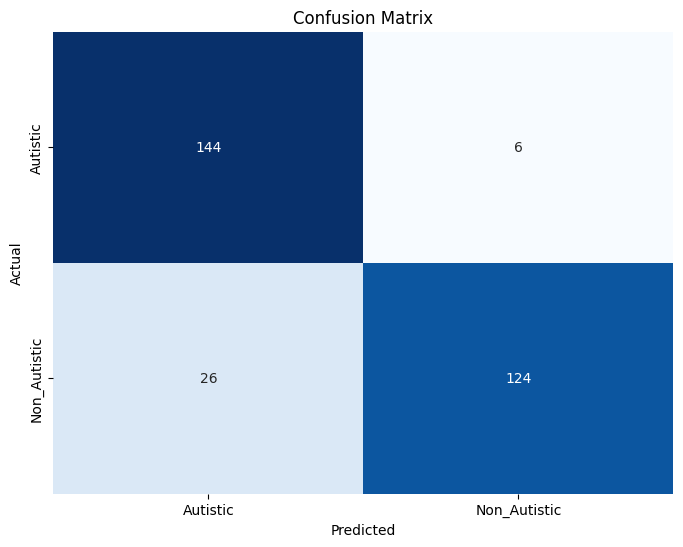

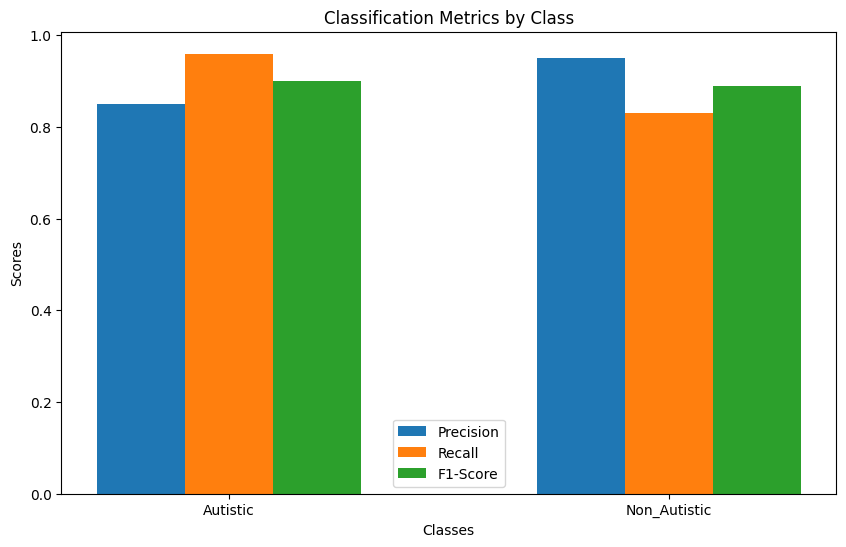

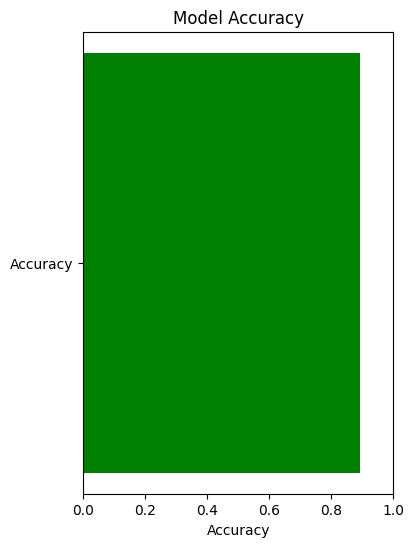

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample data (replace with actual confusion matrix and classification report)
conf_matrix = np.array([[144, 6], [26, 124]])
classification_rep = {
    'Autistic': {'precision': 0.85, 'recall': 0.96, 'f1-score': 0.90, 'support': 150},
    'Non_Autistic': {'precision': 0.95, 'recall': 0.83, 'f1-score': 0.89, 'support': 150}
}
accuracy = 0.893

# Plot Confusion Matrix
def plot_confusion_matrix(conf_matrix):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Autistic', 'Non_Autistic'],
                yticklabels=['Autistic', 'Non_Autistic'])
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.savefig('/kaggle/working/confusion_matrix.png')  # Save to file
    plt.show()

# Plot Precision, Recall, F1-Score for Each Class
def plot_classification_metrics(classification_rep):
    labels = ['Autistic', 'Non_Autistic']
    precision = [classification_rep['Autistic']['precision'], classification_rep['Non_Autistic']['precision']]
    recall = [classification_rep['Autistic']['recall'], classification_rep['Non_Autistic']['recall']]
    f1_score = [classification_rep['Autistic']['f1-score'], classification_rep['Non_Autistic']['f1-score']]

    x = np.arange(len(labels))  # Label locations
    width = 0.2  # Width of the bars

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width, precision, width, label='Precision')
    ax.bar(x, recall, width, label='Recall')
    ax.bar(x + width, f1_score, width, label='F1-Score')

    ax.set_xlabel('Classes')
    ax.set_ylabel('Scores')
    ax.set_title('Classification Metrics by Class')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    plt.savefig('/kaggle/working/classification_metrics.png')  # Save to file
    plt.show()

# Plot Accuracy
def plot_accuracy(accuracy):
    plt.figure(figsize=(4, 6))
    plt.barh(['Accuracy'], [accuracy], color='green')
    plt.xlim([0, 1])
    plt.xlabel('Accuracy')
    plt.title('Model Accuracy')
    plt.savefig('/kaggle/working/accuracy.png')  # Save to file
    plt.show()

# Generate and save the plots
plot_confusion_matrix(conf_matrix)
plot_classification_metrics(classification_rep)
plot_accuracy(accuracy)
